# Attributing the inter-edition temperature difference

The third edition of *Waypoint 2050* revised four things that can move the
2050 temperature outcome: the aircraft **technology** improvement path, the
**operations** improvement, the **SAF** mandate trajectories, and the
**offset** treatment. This notebook separates their contributions by swapping
one group of inputs at a time from the third edition's S1 scenario to its
second-edition analogue.

The swap set is exhaustive: it covers every key on which the two scenarios'
input files differ, so the attribution closes on the observed gap rather than
leaving an unexplained remainder.

**Which scenarios are analogous.** The editions renamed and swapped their
scenarios — the third edition's S1 descends from the second edition's S2. The
input files corroborate this: 2nd-ed S2 already carries the third edition's
later-year technology gains (1.6 / 1.3 %/yr for 2040 / 2050) and differs only in
the early years, which is exactly the disclosed revision.

**What is swapped**

| Group | 3rd ed. S1 | 2nd ed. S2 |
|---|---|---|
| Technology (`*_energy_per_ask_dropin_fuel_gain_*`) | `[0.5, 0.7, 1.6, 1.3]` | `[0.3, 0.5, 1.6, 1.3]` |
| Operations (`operations_gain_*`) | `[0, 6]` %/yr | `[0, 3]` %/yr |
| SAF mandates | `3rd_edition_full/data_inputs/s1_energy.yaml` | `2nd_edition_full/data_inputs/s2_energy.yaml` |
| Residual offset share | `[0, 0, 7, 20, 50, 100]` on `[2020, 2035, 2036, 2040, 2045, 2050]` | `[0, 0, 100]` on `[2020, 2035, 2050]` |
| Prescribed (CORSIA) offsets | present, peaking 163.2 Mt in 2034 | absent |
| CORSIA baseline level | `999999.0` (uncapped) | `100.0` |

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import utils
from utils import COLORS, INK_MUTED, INK_PRIMARY, INK_SECONDARY, style_axes

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlecolor": INK_PRIMARY,
})

from aeromaps import create_process

THIRD = utils.BASE / "3rd_edition_full"
HERE = utils.BASE / "climate_analysis"

MARKETS = ["short_range", "medium_range", "long_range"]
TECH_3RD = [0.5, 0.7, 1.6, 1.3]
TECH_2ND = [0.3, 0.5, 1.6, 1.3]

OPERATIONS_2ND = {"operations_gain_reference_years_values": [0, 3]}

OFFSET_2ND = {
    "residual_carbon_offset_share_reference_years": [2020, 2035, 2050],
    "residual_carbon_offset_share_reference_years_values": [0.0, 0.0, 100.0],
    # The second edition has no prescribed CORSIA path; a flat zero series
    # reproduces its absence without removing the parameter.
    "prescribed_carbon_offset_reference_years": [2020, 2050],
    "prescribed_carbon_offset_reference_years_values": [0.0, 0.0],
    "carbon_offset_baseline_level_vs_corsia_reference_year_reference_periods_values": [100.0],
}


def run(config_dir, config_name, overrides=None):
    """Run one scenario with optional parameter overrides; return its outputs."""
    cwd = os.getcwd()
    os.chdir(config_dir)
    try:
        process = create_process(f"./config_files/{config_name}")
        for key, value in (overrides or {}).items():
            setattr(process.parameters, key, value)
        process.compute()
        return process.data["climate_outputs"].copy(), process.data["vector_outputs"].copy()
    finally:
        os.chdir(cwd)


def tech_override(values):
    return {f"{m}_energy_per_ask_dropin_fuel_gain_reference_years_values": list(values)
            for m in MARKETS}


print("ready")

ready


## The four runs

Each swap is applied on its own against the third-edition S1 baseline, so the
contributions are individually attributable. The interaction residual — the
difference between the sum of the individual swaps and the full swap — is
reported rather than absorbed silently.

In [2]:
runs = {}

runs["baseline (3rd ed. S1)"] = run(THIRD, "config_s1.yaml")
runs["technology -> 2nd ed."] = run(THIRD, "config_s1.yaml", tech_override(TECH_2ND))
runs["operations -> 2nd ed."] = run(THIRD, "config_s1.yaml", OPERATIONS_2ND)
runs["offsets -> 2nd ed."] = run(THIRD, "config_s1.yaml", OFFSET_2ND)
runs["SAF -> 2nd ed."] = run(HERE, "config_s1_saf_2nd_edition.yaml")
runs["all four -> 2nd ed."] = run(
    HERE, "config_s1_saf_2nd_edition.yaml",
    {**tech_override(TECH_2ND), **OPERATIONS_2ND, **OFFSET_2ND},
)

reference = utils.load_climate("2nd_edition_full", "s2")

T = "temperature_increase_from_aviation"
baseline_t = runs["baseline (3rd ed. S1)"][0][T].loc[2050]
print(f"3rd ed. S1 (baseline)     : {1000 * baseline_t:.3f} mK")
print(f"2nd ed. S2 (target)       : {1000 * reference[T].loc[2050]:.3f} mK")
print(f"difference to explain     : "
      f"{1000 * (reference[T].loc[2050] - baseline_t):+.3f} mK")

3rd ed. S1 (baseline)     : 87.687 mK
2nd ed. S2 (target)       : 87.922 mK
difference to explain     : +0.236 mK


## Attribution

In [3]:
rows = []
for name, (clim, _) in runs.items():
    if name.startswith("baseline"):
        continue
    delta = clim[T].loc[2050] - baseline_t
    rows.append({"swap": name, "dT2050 [mK]": 1000 * delta})

attribution = pd.DataFrame(rows).set_index("swap")
individual = attribution.loc[
    ["technology -> 2nd ed.", "operations -> 2nd ed.", "SAF -> 2nd ed.",
     "offsets -> 2nd ed."], "dT2050 [mK]"
]
combined = attribution.loc["all four -> 2nd ed.", "dT2050 [mK]"]
residual = combined - individual.sum()

attribution.loc["sum of individual swaps"] = individual.sum()
attribution.loc["interaction residual"] = residual
display(attribution.round(4))

print(f"\nsum of individual swaps : {individual.sum():+.4f} mK")
print(f"full swap               : {combined:+.4f} mK")
print(f"interaction residual    : {residual:+.4f} mK "
      f"({abs(residual / combined):.1%} of the full swap)")

# The swap set covers every differing input, so the full swap must land on the
# second-edition analogue.
target = 1000 * (reference[T].loc[2050] - baseline_t)
print(f"\nfull swap                : {combined:+.4f} mK")
print(f"actual inter-edition gap : {target:+.4f} mK")
print(f"unexplained              : {combined - target:+.4f} mK")
assert abs(combined - target) < 0.02, (
    "the swap set does not reproduce the inter-edition difference; an input "
    "group is missing from the attribution"
)
print("PASS - the four swaps account for the inter-edition difference")

,dT2050 [mK]
swap,
technology -> 2nd ed.,0.8885
operations -> 2nd ed.,1.0543
offsets -> 2nd ed.,0.0000
SAF -> 2nd ed.,-1.7647
all four -> 2nd ed.,0.2357
sum of individual swaps,0.1782
interaction residual,0.0575



sum of individual swaps : +0.1782 mK
full swap               : +0.2357 mK
interaction residual    : +0.0575 mK (24.4% of the full swap)

full swap                : +0.2357 mK
actual inter-edition gap : +0.2357 mK
unexplained              : +0.0000 mK
PASS - the four swaps account for the inter-edition difference


## The offset finding

Offsets are accounted outside the physical emissions stream: they reduce the
*reported* net figure without changing what leaves an engine. The climate module
is driven by physical emissions, so switching the entire offset treatment
between editions should leave the temperature trajectory untouched — not
approximately, but exactly.

The third edition assigns a substantial share of its residual abatement to
market-based measures. The assertion below establishes that none of it reaches
the climate module.

In [4]:
baseline_clim, baseline_vec = runs["baseline (3rd ed. S1)"]
offset_clim, offset_vec = runs["offsets -> 2nd ed."]

cumulative_baseline = baseline_vec["cumulative_carbon_offset"].iloc[-1]
cumulative_swapped = offset_vec["cumulative_carbon_offset"].iloc[-1]
print(f"cumulative offsets, 3rd ed. treatment : {cumulative_baseline:.3f} Gt")
print(f"cumulative offsets, 2nd ed. treatment : {cumulative_swapped:.3f} Gt")
print(f"difference                            : "
      f"{cumulative_swapped - cumulative_baseline:+.3f} Gt")

difference = (offset_clim[T] - baseline_clim[T]).abs().max()
print(f"\nlargest temperature difference over 1940-2050: {difference:.3e} K")
assert difference == 0.0, (
    "the offset swap changed the temperature trajectory; offsets are no longer "
    "outside the physical emissions stream"
)
print("PASS - changing the entire offset treatment moves the temperature "
      "trajectory by exactly zero")

cumulative offsets, 3rd ed. treatment : 5.104 Gt
cumulative offsets, 2nd ed. treatment : 5.787 Gt
difference                            : +0.683 Gt

largest temperature difference over 1940-2050: 0.000e+00 K
PASS - changing the entire offset treatment moves the temperature trajectory by exactly zero


## Figure — where the inter-edition difference comes from

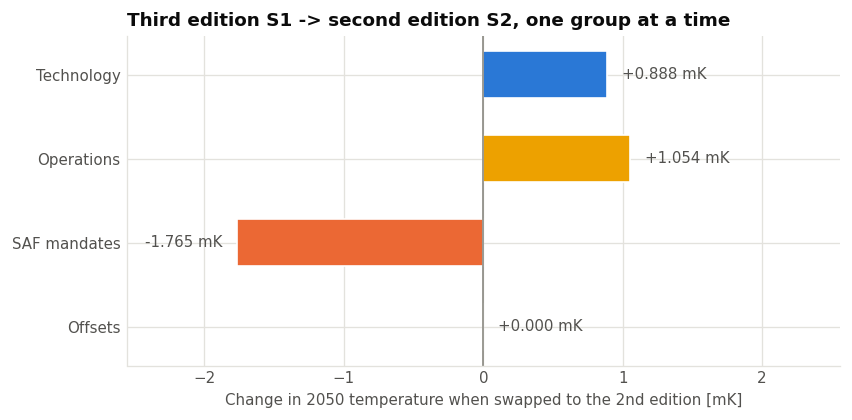

In [5]:
order = ["technology -> 2nd ed.", "operations -> 2nd ed.", "SAF -> 2nd ed.",
         "offsets -> 2nd ed."]
labels = ["Technology", "Operations", "SAF mandates", "Offsets"]
values = [attribution.loc[k, "dT2050 [mK]"] for k in order]
colours = [COLORS["co2"], COLORS["h2o"], COLORS["contrails"], COLORS["nox"]]

fig, ax = plt.subplots(figsize=(7.2, 3.6))
bars = ax.barh(np.arange(len(order)), values, height=0.56,
               color=colours, edgecolor="white", linewidth=1.0)
for rect, value in zip(bars, values):
    ha = "left" if value >= 0 else "right"
    pad = 0.06 * max(abs(min(values)), abs(max(values)), 1e-9)
    ax.text(value + (pad if value >= 0 else -pad),
            rect.get_y() + rect.get_height() / 2,
            f"{value:+.3f} mK", va="center", ha=ha, fontsize=9,
            color=INK_SECONDARY)

ax.axvline(0, color=INK_MUTED, linewidth=1)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
style_axes(ax, xlabel="Change in 2050 temperature when swapped to the 2nd edition [mK]")
ax.set_title("Third edition S1 -> second edition S2, one group at a time", loc="left")
span = max(abs(min(values)), abs(max(values)))
ax.set_xlim(-1.45 * span, 1.45 * span)
fig.tight_layout()
fig.savefig("fig4_edition_attribution.pdf")
plt.show()

## Technology interpolation across the prospection boundary

The technology gain curves are anchored at 2019, which now sits inside the
observed period. Historic energy intensity is data rather than model output, so
the anchor only matters through the value the curve takes at the first
prospective year. This check confirms the modelled intensity is continuous
across the boundary and that no efficiency gain is applied twice.

In [6]:
_, vec = runs["baseline (3rd ed. S1)"]
intensity = vec["energy_consumption"] / vec["ask"]

window = [2021, 2022, 2023, 2024, 2025, 2026]
print("energy intensity [MJ/ASK]")
for year in window:
    marker = "  <- first prospective year" if year == 2024 else ""
    print(f"  {year}  {intensity.loc[year]:.4f}{marker}")

step = abs(intensity.loc[2024] / intensity.loc[2023] - 1)
typical = abs(intensity.loc[2026] / intensity.loc[2025] - 1)
print(f"\nyear-on-year change at the boundary : {step:.3%}")
print(f"typical prospective year-on-year    : {typical:.3%}")
assert step < 0.05, "energy intensity jumps at the prospection boundary"
print("PASS - intensity is continuous across the boundary")

energy intensity [MJ/ASK]
  2021  1.1924
  2022  1.1842
  2023  1.1758
  2024  1.1605  <- first prospective year
  2025  1.1520
  2026  1.1433

year-on-year change at the boundary : 1.304%
typical prospective year-on-year    : 0.752%
PASS - intensity is continuous across the boundary
